# Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', 500) 

In [2]:
df = pd.read_csv('mushroom-dataset/mushrooms.csv')

## Data Cleaning

In [3]:
df["stalk-root"].value_counts()

stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64

In [4]:
df["stalk-root"] = df["stalk-root"].replace("?", "u")
df["stalk-root"].value_counts()

stalk-root
b    3776
u    2480
e    1120
c     556
r     192
Name: count, dtype: int64

In [5]:
df = df.drop("veil-type", axis=1)
print(df.shape)

(8124, 22)


## Dataset Encoding

In [6]:
df_le = df.copy()
le = LabelEncoder()
for col in df_le.columns:
    df_le[col] = le.fit_transform(df_le[col])
df_le.head(10)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,0,2,2,2,7,7,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,0,1,2,2,7,7,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,0,1,2,2,7,7,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,0,2,2,2,7,7,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,1,2,2,2,7,7,2,1,0,3,0,1
5,0,5,3,9,1,0,1,0,0,5,0,1,2,2,7,7,2,1,4,2,2,1
6,0,0,2,8,1,0,1,0,0,2,0,1,2,2,7,7,2,1,4,2,2,3
7,0,0,3,8,1,3,1,0,0,5,0,1,2,2,7,7,2,1,4,3,3,3
8,1,5,3,8,1,6,1,0,1,7,0,2,2,2,7,7,2,1,4,2,4,1
9,0,0,2,9,1,0,1,0,0,2,0,1,2,2,7,7,2,1,4,2,3,3


In [7]:
df_ohe = pd.get_dummies(df, drop_first=True)
df_ohe.head(10)

,class_p,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,cap-color_g,cap-color_n,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,bruises_t,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,gill-attachment_f,gill-spacing_w,gill-size_n,gill-color_e,gill-color_g,gill-color_h,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stalk-shape_t,stalk-root_c,stalk-root_e,stalk-root_r,stalk-root_u,stalk-surface-above-ring_k,stalk-surface-above-ring_s,stalk-surface-above-ring_y,stalk-surface-below-ring_k,stalk-surface-below-ring_s,stalk-surface-below-ring_y,stalk-color-above-ring_c,stalk-color-above-ring_e,stalk-color-above-ring_g,stalk-color-above-ring_n,stalk-color-above-ring_o,stalk-color-above-ring_p,stalk-color-above-ring_w,stalk-color-above-ring_y,stalk-color-below-ring_c,stalk-color-below-ring_e,stalk-color-below-ring_g,stalk-color-below-ring_n,stalk-color-below-ring_o,stalk-color-below-ring_p,stalk-color-below-ring_w,stalk-color-below-ring_y,veil-color_o,veil-color_w,veil-color_y,ring-number_o,ring-number_t,ring-type_f,ring-type_l,ring-type_n,ring-type_p,spore-print-color_h,spore-print-color_k,spore-print-color_n,spore-print-color_o,spore-print-color_r,spore-print-color_u,spore-print-color_w,spore-print-color_y,population_c,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,Fals

Now we have both a label encoded dataset and a one hot encoded dataset.

# Chi-square test
We do the chi-square test on all features with  the class column to see if there are independent features

In [8]:
results = []

for column in df.columns:
    if column == "class":
        continue

    contingency = pd.crosstab(df[column], df["class"])
    chi2, p, dof, expected = chi2_contingency(contingency)

    results.append({
        "Feature": column,
        "p-value": p
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("p-value", ascending=False)

print(results_df)

                     Feature        p-value
9                stalk-shape   4.604746e-20
5            gill-attachment   5.501707e-31
15                veil-color   3.320973e-41
1                cap-surface   5.518427e-68
2                  cap-color   6.055815e-78
16               ring-number   4.235758e-82
0                  cap-shape  1.196457e-103
6               gill-spacing  5.022978e-216
10                stalk-root  7.702048e-290
4                       odor   0.000000e+00
3                    bruises   0.000000e+00
8                 gill-color   0.000000e+00
7                  gill-size   0.000000e+00
12  stalk-surface-below-ring   0.000000e+00
11  stalk-surface-above-ring   0.000000e+00
14    stalk-color-below-ring   0.000000e+00
13    stalk-color-above-ring   0.000000e+00
17                 ring-type   0.000000e+00
18         spore-print-color   0.000000e+00
19                population   0.000000e+00
20                   habitat   0.000000e+00


According to the Chi Square test, every feature is related to the class.

# Cramer's V Test

In [9]:
# Function definition:
def cramers_v(table):
    chi2 = chi2_contingency(table)[0]

    n = table.sum().sum()
    rows, cols = table.shape

    return np.sqrt(chi2 / (n * min(rows - 1, cols - 1)))

In [10]:
results = []

for col in df_le.columns:

    if col == "class":
        continue

    table = pd.crosstab(df[col], df["class"])
    results.append({
        "Feature": col,
        "Cramers_V": cramers_v(table)
    })

results = pd.DataFrame(results)
results.sort_values("Cramers_V", ascending=False)

,Feature,Cramers_V
4,odor,0.971005
18,spore-print-color,0.752645
8,gill-color,0.680830
17,ring-type,0.603271
11,stalk-surface-above-ring,0.587944
12,stalk-surface-below-ring,0.574837
7,gill-size,0.539758
13,stalk-color-above-ring,0.524850
14,stalk-color-below-ring,0.514725
3,bruises,0.501280


# Cramer's Feature Correlation Matrix

In [11]:
import pandas as pd

columns = df.columns

cramers_matrix = pd.DataFrame(
    index=columns,
    columns=columns,
    dtype=float
)

In [12]:
for col1 in columns:
    for col2 in columns:

        table = pd.crosstab(df[col1], df[col2])

        cramers_matrix.loc[col1, col2] = cramers_v(table)

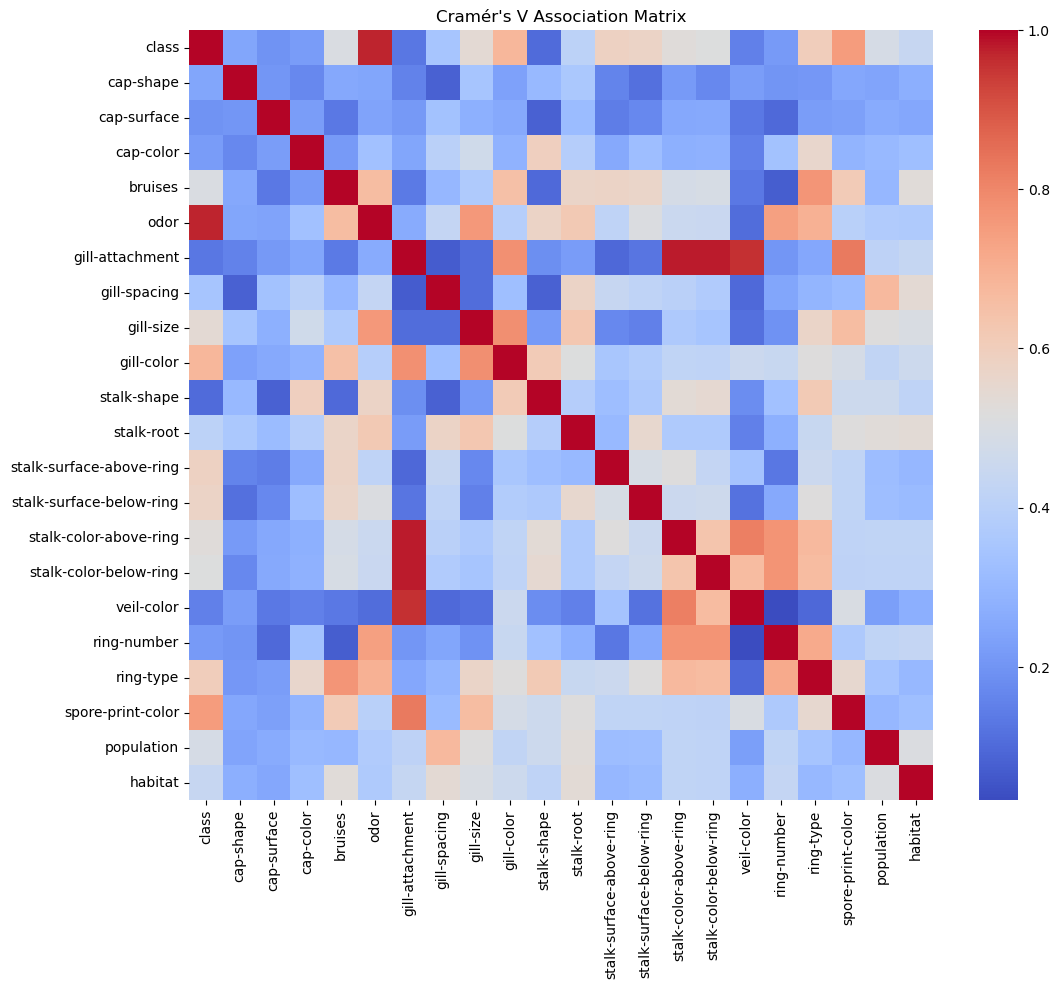

In [13]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    cramers_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Cramér's V Association Matrix")
plt.show()

### What We Notice:

We notice a strong correlation between the following features:
stalk-below-ring/stalk-above-ring are strongly correlated with gill-attachment.
veil color with gill-attachment
gill attachment and spore-print-color are also strobgly correlated.

We'll cramer test them alone:

In [14]:
table_1 = pd.crosstab(df["stalk-color-below-ring"], df["gill-attachment"])
table_2 = pd.crosstab(df["stalk-color-above-ring"], df["gill-attachment"])
table_3 = pd.crosstab(df["veil-color"], df["gill-attachment"])
table_4 = pd.crosstab(df["spore-print-color"], df["gill-attachment"])

cv_1 = cramers_v(table_1)
cv_2 = cramers_v(table_2)
cv_3 = cramers_v(table_3)
cv_4 = cramers_v(table_4)

print(cv_1, cv_2, cv_3, cv_4)

0.9777554049823879 0.977755404982388 0.9550974491634263 0.8268982469225828


#Summary:

From the cramer's analysis, we have our strongest features: 
1. Odor
2. spore-print-color
3. gill-color

Aswell as weakest features:
- veil-color
- gill attachment
- stalk-shape

 as well as from cramer's heatmap, we notice a very strong corrleation between the features: stalk-color-below-ring, stalk-color-above-ring, gill-attachment and veil-color

 from this, since gill-attachment is one of our weakest features, and is strongly correlated with other features, it is safe to be **dropped**, same for veil-color
 this can be done during feature selection just before training the machine learning modles.
